# RallyFlow 🏐 — Pilot Analysis

This notebook contains the analysis for the first **121 rallies** collected with RallyFlow. The goal of this pilot is to test whether the variables collected by RallyFlow reveal useful patterns related to first-ball side-out success and to identify questions worth studying with a larger dataset.

Because not every variable is available or applicable for every rally, sample sizes vary across analyses.

## 1. Setup and Data Loading

Run this cell first. In Google Colab, upload `rallyflow_dataset.xlsx` when prompted. The raw dataset is not embedded in this notebook.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact, chi2_contingency, f_oneway, levene, shapiro
import statsmodels.api as sm

DATA_FILE = "rallyflow_dataset.xlsx"

if not os.path.exists(DATA_FILE):
    try:
        from google.colab import files
        uploaded = files.upload()
        DATA_FILE = next(iter(uploaded))
    except ImportError:
        raise FileNotFoundError("Place rallyflow_dataset.xlsx in the same folder as this notebook.")

df = pd.read_excel(DATA_FILE)

# Shared binary outcome used throughout the notebook
df["sideout_numeric"] = (
    df["successful_first_ball_sideout"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0})
)

print(f"Dataset loaded: {len(df)} rallies, {len(df.columns)} columns")

## 2. Pass Rating and First-Ball Side-Out

**Question:** Does traditional pass rating (0–3) relate to first-ball side-out success?

First, compare observed side-out rates across pass ratings. Then, on the subset with both pass rating and setter displacement available, use logistic regression to examine the relationship and compare pass rating with setter displacement.

In [ ]:
# Keep only rallies with both a pass rating and
# a recorded first-ball side-out result
q1 = df[
    df["pass_rating"].notna() &
    df["successful_first_ball_sideout"].notna()
].copy()

# Convert Yes/No into 1/0
q1["sideout_numeric"] = (
    q1["successful_first_ball_sideout"]
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0})
)

# Summary by pass rating
pass_summary = q1.groupby("pass_rating").agg(
    rallies=("sideout_numeric", "count"),
    successful_sideouts=("sideout_numeric", "sum"),
    sideout_rate=("sideout_numeric", "mean")
)

pass_summary["sideout_percent"] = pass_summary["sideout_rate"] * 100

print("Rallies included:", len(q1))
display(pass_summary)

Rallies included: 109


,rallies,successful_sideouts,sideout_rate,sideout_percent
pass_rating,,,,
0.0,16,0,0.000000,0.000000
1.0,27,1,0.037037,3.703704
2.0,45,7,0.155556,15.555556
3.0,21,10,0.476190,47.619048


In [ ]:
pass_setter = df[
    [
        "pass_rating",
        "setter_displacement_from_target_m",
        "sideout_numeric"
    ]
].copy()

# Convert to numeric
pass_setter["pass_rating"] = pd.to_numeric(
    pass_setter["pass_rating"], errors="coerce"
)

pass_setter["setter_displacement_from_target_m"] = pd.to_numeric(
    pass_setter["setter_displacement_from_target_m"], errors="coerce"
)

# Only rallies with all 3 variables
pass_setter = pass_setter.dropna()

print("Usable rallies:", len(pass_setter))
print("\nSide-out outcomes:")
print(pass_setter["sideout_numeric"].value_counts())

print("\nCorrelation between pass rating and setter displacement:")
print(
    pass_setter[
        ["pass_rating", "setter_displacement_from_target_m"]
    ].corr()
)

Usable rallies: 67

Side-out outcomes:
sideout_numeric
0.0    50
1.0    17
Name: count, dtype: int64

Correlation between pass rating and setter displacement:
                                   pass_rating  \
pass_rating                            1.00000   
setter_displacement_from_target_m     -0.79294   

                                   setter_displacement_from_target_m  
pass_rating                                                 -0.79294  
setter_displacement_from_target_m                            1.00000  


In [ ]:
import statsmodels.api as sm

y = pass_setter["sideout_numeric"]

# MODEL A: Pass rating only
X_pass = sm.add_constant(pass_setter[["pass_rating"]])
model_pass = sm.Logit(y, X_pass).fit(disp=False)

# MODEL B: Setter displacement only
X_setter = sm.add_constant(
    pass_setter[["setter_displacement_from_target_m"]]
)
model_setter = sm.Logit(y, X_setter).fit(disp=False)

# MODEL C: Both together
X_both = sm.add_constant(
    pass_setter[
        ["pass_rating", "setter_displacement_from_target_m"]
    ]
)
model_both = sm.Logit(y, X_both).fit(disp=False)


print("========== MODEL A: PASS RATING ==========")
print(model_pass.summary())

print("\n========== MODEL B: SETTER DISPLACEMENT ==========")
print(model_setter.summary())

print("\n========== MODEL C: BOTH ==========")
print(model_both.summary())

========== MODEL A: PASS RATING ==========
                           Logit Regression Results                           
Dep. Variable:        sideout_numeric   No. Observations:                   67
Model:                          Logit   Df Residuals:                       65
Method:                           MLE   Df Model:                            1
Date:                Fri, 18 Sep 2026   Pseudo R-squ.:                 0.09126
Time:                        04:31:29   Log-Likelihood:                -34.485
converged:                       True   LL-Null:                       -37.949
Covariance Type:            nonrobust   LLR p-value:                  0.008492
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -4.0462      1.297     -3.119      0.002      -6.589      -1.503
pass_rating     1.2835      0.522      2.456      0.014       0.259       2.308

====

### Interpretation
First-ball side-out success increased from **0% on 0-passes to 47.6% on 3-passes**. In the 67-rally regression subset, higher pass rating was significantly associated with greater first-ball side-out success (**p = .014**). Pass rating and setter displacement were also strongly related (**r ≈ −0.793**), which is important when interpreting them together.

## 3. Setter Displacement and First-Ball Side-Out

**Question:** How does setter displacement from the ideal passing target relate to first-ball side-out success?

In [ ]:
# Create the numeric side-out variable again
df["sideout_numeric"] = (
    df["successful_first_ball_sideout"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0})
)

# Create cleaned setter-displacement dataset
setter_q2 = df[
    ["setter_displacement_from_target_m", "sideout_numeric"]
].copy()

setter_q2["setter_displacement_from_target_m"] = pd.to_numeric(
    setter_q2["setter_displacement_from_target_m"],
    errors="coerce"
)

setter_q2 = setter_q2.dropna()

print("Usable rallies:", len(setter_q2))
print()
print(setter_q2["sideout_numeric"].value_counts())

Usable rallies: 67

sideout_numeric
0.0    50
1.0    17
Name: count, dtype: int64


In [ ]:
setter_q2 = df[
    df["setter_displacement_from_target_m"].notna() &
    df["successful_first_ball_sideout"].notna()
].copy()

setter_q2.groupby("successful_first_ball_sideout")[
    "setter_displacement_from_target_m"
].describe()

,count,mean,std,min,25%,50%,75%,max
successful_first_ball_sideout,,,,,,,,
No,50.0,2.298800,1.198250,0.38,1.54,2.25,2.81,5.50
Yes,17.0,1.522941,1.037767,0.21,0.69,1.35,2.32,3.45


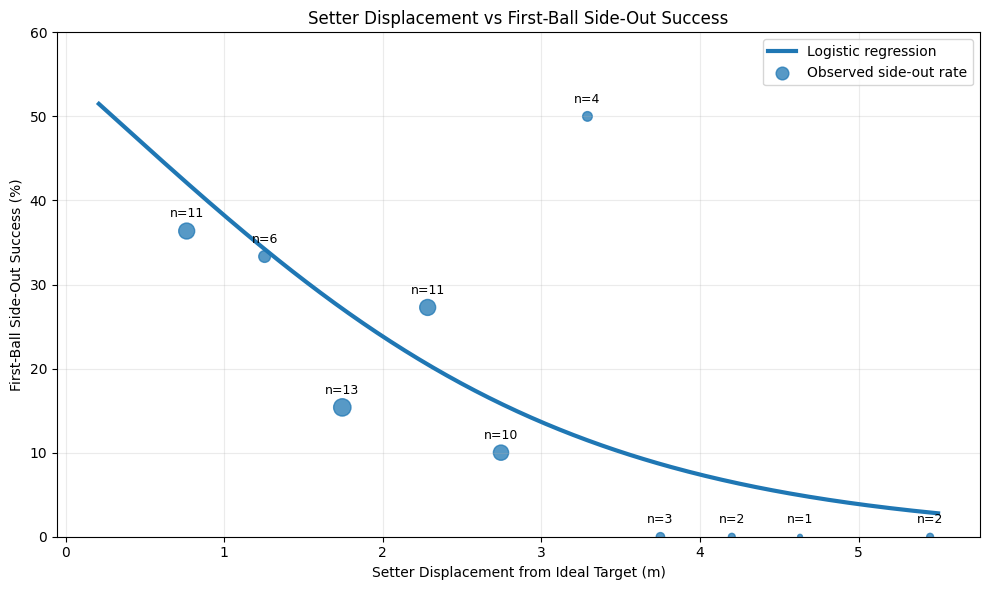

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# -----------------------------
# 1. Logistic regression
# -----------------------------
X = sm.add_constant(
    setter_q2["setter_displacement_from_target_m"]
)
y = setter_q2["sideout_numeric"]

model = sm.Logit(y, X).fit(disp=False)

# Values for smooth regression curve
x_range = np.linspace(
    setter_q2["setter_displacement_from_target_m"].min(),
    setter_q2["setter_displacement_from_target_m"].max(),
    300
)

X_pred = sm.add_constant(x_range)
predicted_probability = model.predict(X_pred) * 100


# -----------------------------
# 2. Create 0.5-meter bins
# -----------------------------
bins = np.arange(
    0,
    setter_q2["setter_displacement_from_target_m"].max() + 0.5,
    0.5
)

setter_q2["displacement_bin"] = pd.cut(
    setter_q2["setter_displacement_from_target_m"],
    bins=bins,
    include_lowest=True
)

observed = (
    setter_q2
    .groupby("displacement_bin", observed=True)
    .agg(
        mean_displacement=("setter_displacement_from_target_m", "mean"),
        sideout_rate=("sideout_numeric", "mean"),
        n=("sideout_numeric", "size")
    )
    .reset_index()
)

observed["sideout_rate"] *= 100


# -----------------------------
# 3. Plot
# -----------------------------
plt.figure(figsize=(10, 6))

# Logistic regression curve
plt.plot(
    x_range,
    predicted_probability,
    linewidth=3,
    label="Logistic regression"
)

# Observed rates
plt.scatter(
    observed["mean_displacement"],
    observed["sideout_rate"],
    s=observed["n"] * 12,
    alpha=0.75,
    label="Observed side-out rate"
)

# Add n labels
for _, row in observed.iterrows():
    plt.annotate(
        f"n={int(row['n'])}",
        (row["mean_displacement"], row["sideout_rate"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

plt.xlabel("Setter Displacement from Ideal Target (m)")
plt.ylabel("First-Ball Side-Out Success (%)")
plt.title("Setter Displacement vs First-Ball Side-Out Success")

plt.ylim(0, 60)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()

### Interpretation
Successful first-ball side-outs had lower average setter displacement (**1.52 m**) than unsuccessful attempts (**2.30 m**). Logistic regression showed a significant negative relationship between displacement and first-ball side-out success (**p = .026**).

## 4. In-System vs. Out-of-System

**Question:** Does system status relate to first-ball side-out success?

In [ ]:
system_analysis = df[
    [
        "system_status",
        "pass_rating",
        "setter_displacement_from_target_m"
    ]
].copy()

# Only use the two meaningful system categories
system_analysis = system_analysis[
    system_analysis["system_status"].isin(
        ["In-system", "Out-of-system"]
    )
]

print("NUMBER OF RALLIES:")
print(system_analysis["system_status"].value_counts())

print("\nAVERAGE PASS RATING:")
print(
    system_analysis.groupby("system_status")["pass_rating"].mean()
)

print("\nAVERAGE SETTER DISPLACEMENT (m):")
print(
    system_analysis.groupby("system_status")[
        "setter_displacement_from_target_m"
    ].mean()
)

NUMBER OF RALLIES:
system_status
In-system        65
Out-of-system    23
Name: count, dtype: int64

AVERAGE PASS RATING:
system_status
In-system        2.169231
Out-of-system    1.434783
Name: pass_rating, dtype: float64

AVERAGE SETTER DISPLACEMENT (m):
system_status
In-system        2.073281
Out-of-system    2.713333
Name: setter_displacement_from_target_m, dtype: float64


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# Keep only in-system and out-of-system rallies
system_sideout = df[
    df["system_status"].isin(["In-system", "Out-of-system"])
].copy()

# Remove rallies without a known side-out result
system_sideout = system_sideout.dropna(
    subset=["sideout_numeric"]
)

# Create 2x2 table
table = pd.crosstab(
    system_sideout["system_status"],
    system_sideout["sideout_numeric"]
)

print("ACTUAL COUNTS:")
print(table)

# Calculate expected counts
chi2, p, dof, expected = chi2_contingency(table)

expected_table = pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns
)

print("\nEXPECTED COUNTS:")
print(expected_table.round(2))

ACTUAL COUNTS:
sideout_numeric  0.0  1.0
system_status            
In-system         48   17
Out-of-system     22    1

EXPECTED COUNTS:
sideout_numeric   0.0   1.0
system_status              
In-system        51.7  13.3
Out-of-system    18.3   4.7


In [ ]:
from scipy.stats import fisher_exact

# Arrange table:
#                Successful   Failed
# In-system          17         48
# Out-of-system       1         22

fisher_table = [
    [17, 48],
    [1, 22]
]

odds_ratio, p_value = fisher_exact(fisher_table)

print("Fisher's Exact Test")
print("-------------------")
print(f"Odds ratio: {odds_ratio:.3f}")
print(f"P-value: {p_value:.4f}")

Fisher's Exact Test
-------------------
Odds ratio: 7.792
P-value: 0.0335


### Interpretation
In-system rallies had a **26.2%** first-ball side-out rate (17/65), compared with **4.3%** for out-of-system rallies (1/23). Fisher's exact test gave **p = .0335**.

## 5. Set Location

**Question:** How does set location relate to first-ball side-out success?

In [ ]:
# Keep rallies with both set location and side-out result
set_analysis = df[
    ["set_location", "sideout_numeric"]
].dropna().copy()

# Create count table
set_table = pd.crosstab(
    set_analysis["set_location"],
    set_analysis["sideout_numeric"]
)

# Add totals and success rates
set_summary = set_table.copy()

set_summary["Total"] = set_summary.sum(axis=1)

if 1.0 in set_summary.columns:
    set_summary["Success Rate (%)"] = (
        set_summary[1.0] / set_summary["Total"] * 100
    )

print("SET LOCATION RESULTS:")
print(set_summary)

print("\nTotal usable rallies:", len(set_analysis))

SET LOCATION RESULTS:
sideout_numeric  0.0  1.0  Total  Success Rate (%)
set_location                                      
1.0                2    0      2          0.000000
2.0               20    6     26         23.076923
3.0                8    5     13         38.461538
4.0               26    7     33         21.212121
5.0                3    0      3          0.000000
6.0               12    0     12          0.000000

Total usable rallies: 89


In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

# Original count table
table = pd.crosstab(
    set_analysis["set_location"],
    set_analysis["sideout_numeric"]
)

chi2, p, dof, expected = chi2_contingency(table)

expected_table = pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns
)

print("ACTUAL COUNTS:")
print(table)

print("\nEXPECTED COUNTS:")
print(expected_table.round(2))

print("\nNumber of expected cells below 5:",
      (expected < 5).sum())

print("Total number of cells:", expected.size)

ACTUAL COUNTS:
sideout_numeric  0.0  1.0
set_location             
1.0                2    0
2.0               20    6
3.0                8    5
4.0               26    7
5.0                3    0
6.0               12    0

EXPECTED COUNTS:
sideout_numeric    0.0   1.0
set_location                
1.0               1.60  0.40
2.0              20.74  5.26
3.0              10.37  2.63
4.0              26.33  6.67
5.0               2.39  0.61
6.0               9.57  2.43

Number of expected cells below 5: 6
Total number of cells: 12


### Interpretation
Set location 3 had the highest observed side-out rate (**38.5%**), but several locations had very small samples and low expected counts. I treat this as exploratory rather than evidence that one set location is best.

## 6. Attack Destination

**Question:** Where are first-ball attacks landing, and does destination relate to attack effectiveness?

The pilot first maps in-bounds attack destinations, then narrows the depth comparison to hard-driven attacks so tips, rolls, tools, and other attack types do not distort the comparison.

In [ ]:
attack_df = df[
    df["attack_destination_x"].notna() &
    df["attack_destination_y"].notna() &
    df["attack_outcome"].notna()
].copy()

print("Usable attacks:", len(attack_df))
print("\nAttack outcomes:")
print(attack_df["attack_outcome"].value_counts())

print("\nDestination ranges:")
print("X:", attack_df["attack_destination_x"].min(),
      "to", attack_df["attack_destination_x"].max())
print("Y:", attack_df["attack_destination_y"].min(),
      "to", attack_df["attack_destination_y"].max())

Usable attacks: 81

Attack outcomes:
attack_outcome
Continued    54
Kill         16
Error         9
Tool kill     2
Name: count, dtype: int64

Destination ranges:
X: -0.72 to 9.64
Y: -0.82 to 8.58


In [ ]:
import numpy as np
import pandas as pd

# Only attacks that landed inside the opponent's court
in_bounds = attack_df[
    attack_df["attack_destination_x"].between(0, 9) &
    attack_df["attack_destination_y"].between(0, 9)
].copy()

# Count kills + tool kills as successful attacks
in_bounds["attack_success"] = (
    in_bounds["attack_outcome"].isin(["Kill", "Tool kill"])
).astype(int)

# Create 1.5 m zones
bins = np.arange(0, 9.01, 1.5)

in_bounds["x_zone"] = pd.cut(
    in_bounds["attack_destination_x"],
    bins=bins,
    include_lowest=True
)

in_bounds["y_zone"] = pd.cut(
    in_bounds["attack_destination_y"],
    bins=bins,
    include_lowest=True
)

zone_stats = (
    in_bounds
    .groupby(["x_zone", "y_zone"], observed=True)
    .agg(
        attacks=("attack_success", "size"),
        kills=("attack_success", "sum")
    )
    .reset_index()
)

zone_stats["kill_rate"] = (
    zone_stats["kills"] / zone_stats["attacks"] * 100
)

print("In-bounds attacks:", len(in_bounds))
print(zone_stats.sort_values("attacks", ascending=False).to_string(index=False))

In-bounds attacks: 73
       x_zone        y_zone  attacks  kills  kill_rate
   (1.5, 3.0]    (1.5, 3.0]       13      2  15.384615
   (3.0, 4.5]    (1.5, 3.0]        7      1  14.285714
   (4.5, 6.0]    (1.5, 3.0]        6      1  16.666667
   (6.0, 7.5]    (1.5, 3.0]        4      1  25.000000
   (3.0, 4.5]    (4.5, 6.0]        3      3 100.000000
   (3.0, 4.5]    (6.0, 7.5]        3      0   0.000000
   (1.5, 3.0] (-0.001, 1.5]        3      3 100.000000
   (4.5, 6.0]    (7.5, 9.0]        3      0   0.000000
   (1.5, 3.0]    (4.5, 6.0]        3      0   0.000000
   (1.5, 3.0]    (3.0, 4.5]        2      0   0.000000
   (1.5, 3.0]    (6.0, 7.5]        2      0   0.000000
(-0.001, 1.5]    (7.5, 9.0]        2      1  50.000000
   (6.0, 7.5]    (3.0, 4.5]        2      1  50.000000
   (4.5, 6.0]    (4.5, 6.0]        2      0   0.000000
   (3.0, 4.5]    (7.5, 9.0]        2      1  50.000000
   (3.0, 4.5]    (3.0, 4.5]        2      0   0.000000
(-0.001, 1.5]    (1.5, 3.0]        2      1

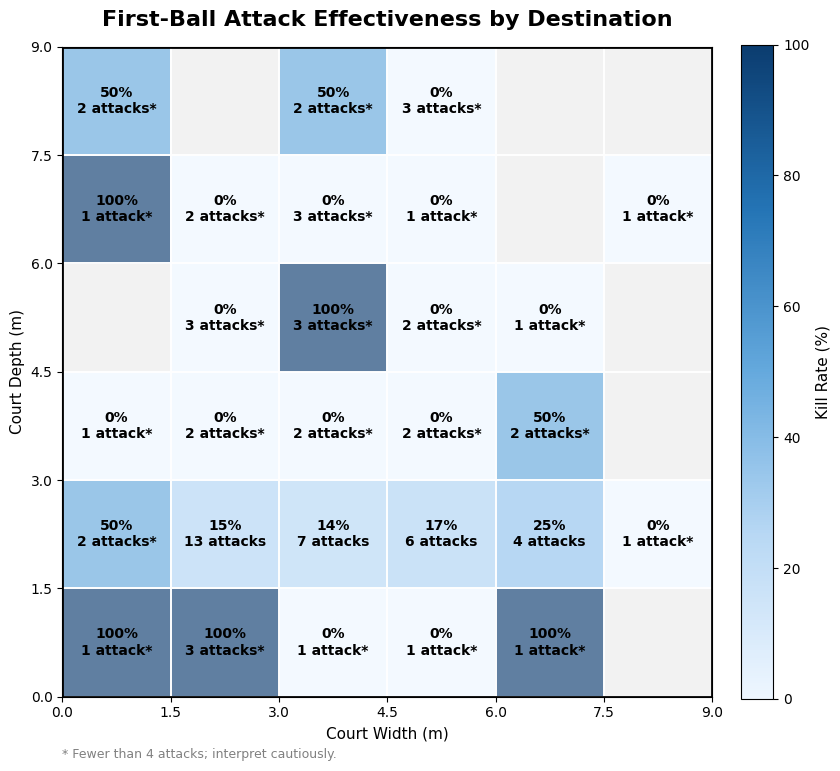

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

# Build matrices
kill_rate_map = np.full((6, 6), np.nan)
sample_size_map = np.zeros((6, 6))

for _, row in zone_stats.iterrows():
    x_mid = row["x_zone"].mid
    y_mid = row["y_zone"].mid

    x_idx = min(int(x_mid // 1.5), 5)
    y_idx = min(int(y_mid // 1.5), 5)

    kill_rate_map[y_idx, x_idx] = row["kill_rate"]
    sample_size_map[y_idx, x_idx] = row["attacks"]

# Blue color scale
cmap = LinearSegmentedColormap.from_list(
    "volleyball_blue",
    ["#EEF6FF", "#B8D8F4", "#65A9DD", "#2474B5", "#0B3C6F"]
)

cmap.set_bad("#F2F2F2")

fig, ax = plt.subplots(figsize=(8.5, 8))

im = ax.imshow(
    kill_rate_map,
    origin="lower",
    extent=[0, 9, 0, 9],
    aspect="equal",
    cmap=cmap,
    vmin=0,
    vmax=100
)

# Court/grid lines
for value in np.arange(0, 9.01, 1.5):
    ax.axvline(value, color="white", linewidth=1.4)
    ax.axhline(value, color="white", linewidth=1.4)

# Fade low-sample zones
for y in range(6):
    for x in range(6):

        n = int(sample_size_map[y, x])

        if 0 < n < 4:
            rect = Rectangle(
                (x * 1.5, y * 1.5),
                1.5,
                1.5,
                facecolor="white",
                alpha=0.35,
                edgecolor="none"
            )
            ax.add_patch(rect)

# Outer court boundary
ax.plot(
    [0, 9, 9, 0, 0],
    [0, 0, 9, 9, 0],
    color="black",
    linewidth=2
)

# Text labels
for y in range(6):
    for x in range(6):

        n = int(sample_size_map[y, x])

        if n > 0:
            rate = kill_rate_map[y, x]

            attack_word = "attack" if n == 1 else "attacks"

            # Mark low-sample zones
            sample_marker = "*" if n < 4 else ""

            # Text color
            if n < 4:
                text_color = "black"
            else:
                text_color = "white" if rate >= 55 else "black"

            ax.text(
                x * 1.5 + 0.75,
                y * 1.5 + 0.75,
                f"{rate:.0f}%\n{n} {attack_word}{sample_marker}",
                ha="center",
                va="center",
                fontsize=10,
                fontweight="semibold",
                color=text_color
            )

ax.set_xlim(0, 9)
ax.set_ylim(0, 9)

ax.set_xticks(np.arange(0, 9.01, 1.5))
ax.set_yticks(np.arange(0, 9.01, 1.5))

ax.set_xlabel("Court Width (m)", fontsize=11)
ax.set_ylabel("Court Depth (m)", fontsize=11)

ax.set_title(
    "First-Ball Attack Effectiveness by Destination",
    fontsize=16,
    fontweight="bold",
    pad=15
)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Kill Rate (%)", fontsize=11)

# Explanation
ax.text(
    0,
    -0.85,
    "* Fewer than 4 attacks; interpret cautiously.",
    fontsize=9,
    color="gray"
)

plt.tight_layout()
plt.show()

In [ ]:
hard = attack_df[
    attack_df["attack_type"] == "Hard-driven"
].copy()

hard["in_bounds"] = (
    hard["attack_destination_x"].between(0, 9) &
    hard["attack_destination_y"].between(0, 9)
)

hard["depth_zone"] = pd.cut(
    hard["attack_destination_y"],
    bins=[0, 3, 6, 9],
    labels=["Short (0–3 m)", "Middle (3–6 m)", "Deep (6–9 m)"],
    include_lowest=True
)

hard["kill"] = (
    hard["attack_outcome"] == "Kill"
).astype(int)

hard_depth = (
    hard[hard["in_bounds"]]
    .groupby("depth_zone", observed=True)
    .agg(
        attacks=("kill", "size"),
        kills=("kill", "sum")
    )
)

hard_depth["kill_rate"] = (
    hard_depth["kills"] /
    hard_depth["attacks"] * 100
)

print("Hard-driven attacks:", len(hard))
print("\nHard-driven outcomes:")
print(hard["attack_outcome"].value_counts())

print("\nHard-driven attacks by depth:")
print(hard_depth)

Hard-driven attacks: 49

Hard-driven outcomes:
attack_outcome
Continued    26
Kill         14
Error         9
Name: count, dtype: int64

Hard-driven attacks by depth:
                attacks  kills  kill_rate
depth_zone                               
Short (0–3 m)        30     10  33.333333
Middle (3–6 m)        7      3  42.857143
Deep (6–9 m)          4      1  25.000000


In [ ]:
from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency
import pandas as pd

hard_in = hard[hard["in_bounds"]].copy()

table = pd.crosstab(
    hard_in["depth_zone"],
    hard_in["kill"]
)

print("Contingency table:")
print(table)

chi2, p, dof, expected = chi2_contingency(table)

print("\nChi-square:", chi2)
print("p-value:", p)
print("\nExpected counts:")
print(expected)

Contingency table:
kill             0   1
depth_zone            
Short (0–3 m)   20  10
Middle (3–6 m)   4   3
Deep (6–9 m)     3   1

Chi-square: 0.39383345930964975
p-value: 0.8212590169872751

Expected counts:
[[19.75609756 10.24390244]
 [ 4.6097561   2.3902439 ]
 [ 2.63414634  1.36585366]]


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# Keep only hard-driven, in-bounds attacks with a depth zone
test_df = hard_in[
    hard_in["depth_zone"].notna()
].copy()

# Observed chi-square statistic
observed_table = pd.crosstab(
    test_df["depth_zone"],
    test_df["kill"]
)

observed_chi2 = chi2_contingency(
    observed_table,
    correction=False
)[0]

# Permutation test
np.random.seed(42)

n_permutations = 10000
permuted_stats = []

for i in range(n_permutations):

    shuffled = np.random.permutation(test_df["kill"].values)

    perm_table = pd.crosstab(
        test_df["depth_zone"],
        shuffled
    )

    perm_chi2 = chi2_contingency(
        perm_table,
        correction=False
    )[0]

    permuted_stats.append(perm_chi2)

permuted_stats = np.array(permuted_stats)

p_perm = (
    np.sum(permuted_stats >= observed_chi2) + 1
) / (n_permutations + 1)

print("Observed chi-square:", observed_chi2)
print("Permutation p-value:", p_perm)

Observed chi-square: 0.39383345930964975
Permutation p-value: 0.8712128787121288


### Interpretation
For hard-driven, in-bounds attacks, observed kill rates were **33.3% short**, **42.9% middle**, and **25.0% deep**. The groups were small, and the permutation test did not find a significant association between depth and kill outcome (**p ≈ .871**).

## 7. Blockers Faced

**Question:** How does the number of blockers faced relate to first-ball side-out success?

For the main comparison, non-comparable attack types are excluded and one blocker is compared with two blockers.

In [ ]:
# Exclude attack types where blockers faced isn't really comparable
excluded_types = [
    "Free ball",
    "Down ball",
    "Second-touch attack",
    "First-touch return"
]

normal_attacks = df[
    (~df["attack_type"].isin(excluded_types)) &
    (df["blockers_faced"].notna()) &
    (df["sideout_numeric"].notna())
].copy()

normal_blocker_table = pd.crosstab(
    normal_attacks["blockers_faced"],
    normal_attacks["sideout_numeric"]
)

normal_blocker_summary = normal_blocker_table.copy()
normal_blocker_summary["Total"] = normal_blocker_summary.sum(axis=1)

normal_blocker_summary["Success Rate (%)"] = (
    normal_blocker_summary.get(1.0, 0) /
    normal_blocker_summary["Total"] * 100
)

print("BLOCKERS FACED — NORMAL ATTACKS ONLY:")
print(normal_blocker_summary)

print("\nAttack types included:")
print(normal_attacks["attack_type"].value_counts())

print("\nTotal usable attacks:", len(normal_attacks))

BLOCKERS FACED — NORMAL ATTACKS ONLY:
sideout_numeric  0.0  1.0  Total  Success Rate (%)
blockers_faced                                    
0.0                5    0      5               0.0
1.0                9    6     15              40.0
2.0               38   12     50              24.0

Attack types included:
attack_type
Hard-driven    53
Tip             7
Roll shot       6
Tool            4
Name: count, dtype: int64

Total usable attacks: 70


In [ ]:
from scipy.stats import fisher_exact

# Compare 1 blocker vs 2 blockers
# Rows: 1 blocker, 2 blockers
# Columns: Successful, Failed

fisher_table = [
    [6, 9],    # 1 blocker
    [12, 38]   # 2 blockers
]

odds_ratio, p_value = fisher_exact(fisher_table)

print("Odds ratio:", round(odds_ratio, 3))
print("p-value:", round(p_value, 4))

Odds ratio: 2.111
p-value: 0.3235


### Interpretation
Among the normal attacks used here, first-ball side-out success was **40% against one blocker** and **24% against two blockers**. Fisher's exact test did not show a significant difference (**p ≈ .324**).

## 8. Rotation

**Question:** Does first-ball side-out success differ by rotation?

In [ ]:
# Keep rallies with rotation and known first-ball side-out result
rotation_analysis = df[
    ["rotation", "sideout_numeric"]
].dropna().copy()

# Create success/failure table
rotation_table = pd.crosstab(
    rotation_analysis["rotation"],
    rotation_analysis["sideout_numeric"]
)

# Add totals and success rates
rotation_summary = rotation_table.copy()
rotation_summary["Total"] = rotation_summary.sum(axis=1)

rotation_summary["Success Rate (%)"] = (
    rotation_summary[1.0] /
    rotation_summary["Total"] * 100
)

# Put rotations in order
rotation_summary = rotation_summary.reindex(
    ["R1", "R2", "R3", "R4", "R5", "R6"]
)

print("ROTATION RESULTS:")
print(rotation_summary)

print("\nTotal usable rallies:", len(rotation_analysis))

ROTATION RESULTS:
sideout_numeric  0.0  1.0  Total  Success Rate (%)
rotation                                          
R1                16    3     19         15.789474
R2                13    2     15         13.333333
R3                36    4     40         10.000000
R4                12    2     14         14.285714
R5                11    2     13         15.384615
R6                 5    5     10         50.000000

Total usable rallies: 111


In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

chi2, p, dof, expected = chi2_contingency(rotation_table)

expected_table = pd.DataFrame(
    expected,
    index=rotation_table.index,
    columns=rotation_table.columns
)

print("ACTUAL COUNTS:")
print(rotation_table)

print("\nEXPECTED COUNTS:")
print(expected_table.round(2))

print("\nNumber of expected cells below 5:",
      (expected < 5).sum())

print("Total number of cells:", expected.size)

ACTUAL COUNTS:
sideout_numeric  0.0  1.0
rotation                 
R1                16    3
R2                13    2
R3                36    4
R4                12    2
R5                11    2
R6                 5    5

EXPECTED COUNTS:
sideout_numeric    0.0   1.0
rotation                    
R1               15.92  3.08
R2               12.57  2.43
R3               33.51  6.49
R4               11.73  2.27
R5               10.89  2.11
R6                8.38  1.62

Number of expected cells below 5: 5
Total number of cells: 12


In [ ]:
# Compare R6 with all other rotations

r6 = df[
    (df["rotation"] == "R6") &
    (df["sideout_numeric"].notna())
].copy()

other_rotations = df[
    (df["rotation"] != "R6") &
    (df["sideout_numeric"].notna())
].copy()

print("R6:")
print("Rallies:", len(r6))
print("Average pass rating:", round(r6["pass_rating"].mean(), 2))
print("Average setter displacement:",
      round(r6["setter_displacement_from_target_m"].mean(), 2))
print("\nSystem status:")
print(r6["system_status"].value_counts(dropna=False))

print("\n----------------")

print("\nR1-R5:")
print("Rallies:", len(other_rotations))
print("Average pass rating:",
      round(other_rotations["pass_rating"].mean(), 2))
print("Average setter displacement:",
      round(other_rotations["setter_displacement_from_target_m"].mean(), 2))
print("\nSystem status:")
print(other_rotations["system_status"].value_counts(dropna=False))

R6:
Rallies: 10
Average pass rating: 1.9
Average setter displacement: 2.15

System status:
system_status
In-system        8
Out-of-system    1
NaN              1
Name: count, dtype: int64

----------------

R1-R5:
Rallies: 101
Average pass rating: 1.63
Average setter displacement: 2.1

System status:
system_status
In-system        57
Out-of-system    22
NaN              21
Broken play       1
Name: count, dtype: int64


### Interpretation
R6 had the highest observed side-out rate at **50% (5/10)**, while R1–R5 ranged from about 10–16%. Because R6 had only 10 rallies and expected counts were small, this pattern needs much more data before drawing a statistical conclusion.

## 9. Pass Destination and Miss Direction

**Question:** When passes miss the ideal target, where are they actually going?

For this spatial analysis, pass destination is defined as the setter-contact location for rallies in which the setter took the second contact.

In [ ]:
# Pass destination = where the SETTER contacts the pass
pass_destination = df[
    (df["second_contact_by"] == "Setter") &
    (df["setter_contact_x"].notna()) &
    (df["setter_contact_y"].notna()) &
    (df["ideal_target_x"].notna()) &
    (df["ideal_target_y"].notna())
].copy()

# Calculate actual distance from pass destination to ideal target
pass_destination["destination_deviation_m"] = (
    (
        (pass_destination["setter_contact_x"] - pass_destination["ideal_target_x"])**2
        +
        (pass_destination["setter_contact_y"] - pass_destination["ideal_target_y"])**2
    )**0.5
)

print("Usable setter-contact passes:", len(pass_destination))

print("\nBy pass rating:")
print(
    pass_destination.groupby("pass_rating")
    .agg(
        n=("pass_rating", "size"),
        avg_destination_x=("setter_contact_x", "mean"),
        avg_destination_y=("setter_contact_y", "mean"),
        avg_deviation_m=("destination_deviation_m", "mean")
    )
    .round(2)
)

print("\nIdeal target:")
print(
    pass_destination[
        ["ideal_target_x", "ideal_target_y"]
    ].drop_duplicates()
)

Usable setter-contact passes: 67

By pass rating:
              n  avg_destination_x  avg_destination_y  avg_deviation_m
pass_rating                                                           
1.0           8               3.79               2.70             3.93
2.0          38               4.99               2.48             2.38
3.0          21               5.73               1.38             0.90

Ideal target:
   ideal_target_x  ideal_target_y
1            5.64            1.14


In [ ]:
# Difference between pass destination and ideal target
pass_destination["x_difference"] = (
    pass_destination["setter_contact_x"]
    - pass_destination["ideal_target_x"]
)

pass_destination["y_difference"] = (
    pass_destination["setter_contact_y"]
    - pass_destination["ideal_target_y"]
)

# Determine the PRIMARY direction of each miss
def primary_miss(row):

    x = row["x_difference"]
    y = row["y_difference"]

    # Whichever axis has the larger absolute miss
    if abs(x) > abs(y):
        return "+X" if x > 0 else "-X"
    else:
        return "+Y" if y > 0 else "-Y"

pass_destination["primary_miss_direction"] = (
    pass_destination.apply(primary_miss, axis=1)
)

# Count directions
direction_summary = (
    pass_destination["primary_miss_direction"]
    .value_counts()
    .rename_axis("Direction")
    .reset_index(name="Passes")
)

direction_summary["Percent"] = (
    direction_summary["Passes"]
    / direction_summary["Passes"].sum()
    * 100
).round(1)

print(direction_summary)

  Direction  Passes  Percent
0        +Y      28     41.8
1        -X      21     31.3
2        +X      14     20.9
3        -Y       4      6.0


In [ ]:
# Define a 1-meter target zone
TARGET_RADIUS = 1.0

pass_destination["target_status"] = (
    pass_destination["destination_deviation_m"]
    .apply(lambda d: "On target" if d <= TARGET_RADIUS else "Miss")
)

# Keep only passes outside the target zone
misses = pass_destination[
    pass_destination["destination_deviation_m"] > TARGET_RADIUS
].copy()

# Primary direction of each actual miss
def primary_miss(row):
    x = row["x_difference"]
    y = row["y_difference"]

    if abs(x) > abs(y):
        return "+X" if x > 0 else "-X"
    else:
        return "+Y" if y > 0 else "-Y"

misses["miss_direction"] = misses.apply(primary_miss, axis=1)

# Summary
print("Total passes:", len(pass_destination))
print("Within 1 m of target:",
      (pass_destination["target_status"] == "On target").sum())
print("Outside 1 m:",
      len(misses))

print("\nMISS DIRECTIONS:")
summary = misses["miss_direction"].value_counts().to_frame("Passes")

summary["Percent"] = (
    summary["Passes"] / len(misses) * 100
).round(1)

print(summary)

print("\nTARGET RATE BY PASS RATING:")
print(
    pass_destination.groupby("pass_rating")["target_status"]
    .value_counts()
    .unstack(fill_value=0)
)

Total passes: 67
Within 1 m of target: 15
Outside 1 m: 52

MISS DIRECTIONS:
                Passes  Percent
miss_direction                 
+Y                  26     50.0
-X                  19     36.5
+X                   6     11.5
-Y                   1      1.9

TARGET RATE BY PASS RATING:
target_status  Miss  On target
pass_rating                   
1.0               8          0
2.0              38          0
3.0               6         15


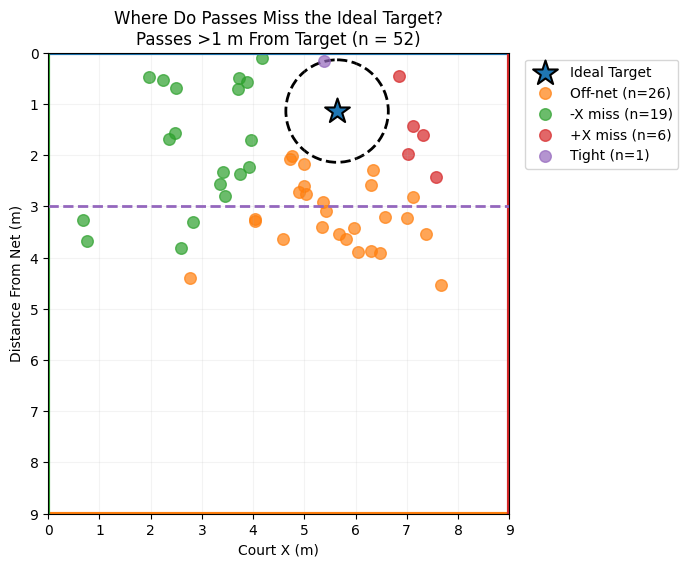

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(7, 8))

# -------------------------
# Court
# -------------------------
ax.plot([0, 9], [0, 0], linewidth=3)       # Net
ax.plot([0, 9], [9, 9], linewidth=3)
ax.plot([0, 0], [0, 9], linewidth=3)
ax.plot([9, 9], [0, 9], linewidth=3)

# 3-meter / 10-foot line
ax.plot([0, 9], [3, 3], linewidth=2, linestyle="--")

# -------------------------
# 1-meter target zone
# -------------------------
target_circle = Circle(
    (5.64, 1.14),
    1.0,
    fill=False,
    linewidth=2,
    linestyle="--"
)

ax.add_patch(target_circle)

# Ideal target
ax.scatter(
    5.64,
    1.14,
    marker="*",
    s=350,
    edgecolor="black",
    linewidth=1.5,
    label="Ideal Target",
    zorder=10
)

# -------------------------
# Plot meaningful misses
# -------------------------
direction_labels = {
    "+Y": "Off-net",
    "-Y": "Tight",
    "-X": "-X miss",
    "+X": "+X miss"
}

for direction in ["+Y", "-X", "+X", "-Y"]:
    subset = misses[
        misses["miss_direction"] == direction
    ]

    ax.scatter(
        subset["setter_contact_x"],
        subset["setter_contact_y"],
        s=70,
        alpha=0.7,
        label=f"{direction_labels[direction]} (n={len(subset)})"
    )

# -------------------------
# Formatting
# -------------------------
ax.set_xlim(0, 9)
ax.set_ylim(9, 0)
ax.set_aspect("equal")

ax.set_xlabel("Court X (m)")
ax.set_ylabel("Distance From Net (m)")

ax.set_title(
    "Where Do Passes Miss the Ideal Target?\n"
    "Passes >1 m From Target (n = 52)"
)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

### Interpretation
Among the 52 passes more than 1 m from the ideal target, **50.0% primarily missed off-net (+Y)**, **36.5% in −X**, **11.5% in +X**, and **1.9% toward the net (−Y)**. All 15 passes within 1 m of the target were rated as 3-passes.

## 10. Setter Travel by Rotation

**Question:** How much does the setter travel in each rotation?

In [ ]:
rotation_travel = df[
    ["rotation", "setter_total_travel_m"]
].copy()

rotation_travel["setter_total_travel_m"] = pd.to_numeric(
    rotation_travel["setter_total_travel_m"],
    errors="coerce"
)

rotation_travel = rotation_travel.dropna()

rotation_summary = (
    rotation_travel
    .groupby("rotation")
    .agg(
        n=("setter_total_travel_m", "size"),
        avg_travel_m=("setter_total_travel_m", "mean"),
        median_travel_m=("setter_total_travel_m", "median")
    )
    .reindex(["R1", "R2", "R3", "R4", "R5", "R6"])
    .round(2)
)

print("Total usable rallies:", len(rotation_travel))
print(rotation_summary)

Total usable rallies: 67
           n  avg_travel_m  median_travel_m
rotation                                   
R1        14          8.21             8.16
R2        11          4.01             4.17
R3        18          5.91             5.65
R4         7          7.96             8.52
R5         9          3.71             3.39
R6         8          4.95             4.96


In [ ]:
from scipy.stats import f_oneway

# Create one travel-distance group for each rotation
groups = [
    rotation_travel.loc[
        rotation_travel["rotation"] == rotation,
        "setter_total_travel_m"
    ]
    for rotation in ["R1", "R2", "R3", "R4", "R5", "R6"]
]

# One-way ANOVA
f_stat, p_value = f_oneway(*groups)

print("One-way ANOVA")
print("F-statistic:", round(f_stat, 3))
print("p-value:", round(p_value, 4))

One-way ANOVA
F-statistic: 25.637
p-value: 0.0


In [ ]:
from scipy.stats import levene, shapiro

# Equal-variance check
levene_stat, levene_p = levene(*groups)

print("Levene's test p-value:", round(levene_p, 4))

print("\nShapiro-Wilk by rotation:")
for rotation, group in zip(
    ["R1", "R2", "R3", "R4", "R5", "R6"],
    groups
):
    stat, p = shapiro(group)
    print(rotation, "p =", round(p, 4))

Levene's test p-value: 0.9887

Shapiro-Wilk by rotation:
R1 p = 0.5348
R2 p = 0.922
R3 p = 0.0117
R4 p = 0.0876
R5 p = 0.1043
R6 p = 0.877


### Interpretation
Average setter travel differed across rotations (**ANOVA F = 25.64, p < .001**). R1 and R4 had the largest average travel distances, while R5 had the smallest. One rotation failed the Shapiro–Wilk normality check, so this result should be interpreted as part of the pilot rather than treated as a final model.

## 11. Pilot Limitations and Next Steps

This is a small pilot dataset, so the goal is not to make universal claims about volleyball. Several analyses have small or uneven group sizes, and variables such as pass rating, setter displacement, and system status are related to one another. The data were also annotated manually from film.

The next steps are to collect substantially more rallies, improve consistency and efficiency in annotation, and test multivariable models that can evaluate whether RallyFlow's spatial measurements add useful information beyond traditional volleyball statistics.